In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/shubhra2001/google-play-store-apps-analysis/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000",Free,0,Everyone,Art & Design,January 7 2018,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"5,00,000",Free,0,Everyone,Art & Design;Pretend Play,January 15 2018,2.0.0,4.0.3 and up
2,U Launcher Lite – FREE Live Cool Themes Hide Apps,ART_AND_DESIGN,4.7,87510,8.7M,"50,00,000",Free,0,Everyone,Art & Design,August 1 2018,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"5,00,00,000",Free,0,Teen,Art & Design,June 8 2018,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"1,00,000",Free,0,Everyone,Art & Design;Creativity,June 20 2018,1.1,4.4 and up


In [2]:
import os
os.listdir('/kaggle/input')

['datasets']

In [3]:
import os
os.listdir('/kaggle/input/datasets')

['shubhra2001']

In [4]:
# Fix Installs
df['Installs'] = df['Installs'].astype(str).str.replace(',', '').str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Fix Price
df['Price'] = df['Price'].astype(str).str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Fix Size
def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return None

df['Size'] = df['Size'].apply(convert_size)

# Convert Date
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Remove duplicates and missing ratings
df.drop_duplicates(inplace=True)
df = df.dropna(subset=['Rating'])

# --- ADD THIS LINE TO SEE THE OUTPUT ---
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,U Launcher Lite – FREE Live Cool Themes Hide Apps,ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8893 entries, 0 to 10357
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             8893 non-null   object        
 1   Category        8893 non-null   object        
 2   Rating          8893 non-null   float64       
 3   Reviews         8893 non-null   object        
 4   Size            7423 non-null   float64       
 5   Installs        8892 non-null   float64       
 6   Type            8893 non-null   object        
 7   Price           8892 non-null   float64       
 8   Content Rating  8892 non-null   object        
 9   Genres          8893 non-null   object        
 10  Last Updated    8892 non-null   datetime64[ns]
 11  Current Ver     8889 non-null   object        
 12  Android Ver     8890 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(8)
memory usage: 972.7+ KB


In [15]:
df.isnull().sum()


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

# remove missing values

In [23]:
df.dropna(inplace=True)

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df.shape

(7417, 13)

In [31]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

# Average Rating

In [6]:
print("Average Rating:", df['Rating'].mean())

Average Rating: 4.18954233666929


# Free vs Paid apps

In [7]:
print("\nFree vs Paid:\n", df['Type'].value_counts())


Free vs Paid:
 Type
Free    8279
Paid     613
0          1
Name: count, dtype: int64


# Top 5 Categories

In [8]:
print("\nTop Categories:\n", df['Category'].value_counts().head())


Top Categories:
 Category
FAMILY          1718
GAME            1074
TOOLS            734
PRODUCTIVITY     334
FINANCE          317
Name: count, dtype: int64


# 1. Installs vs Rating

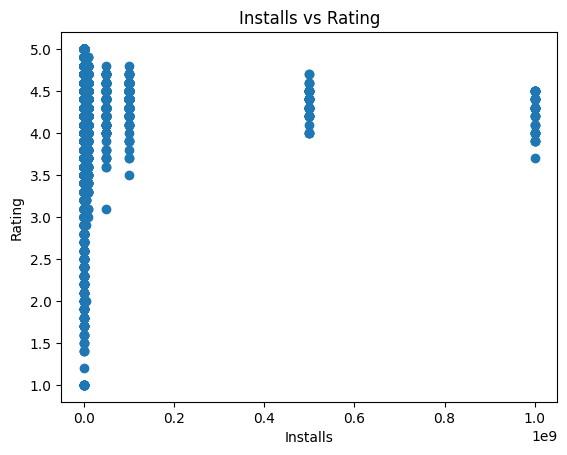

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['Installs'], df['Rating'])
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")
plt.show()

# 2. Category Distribution

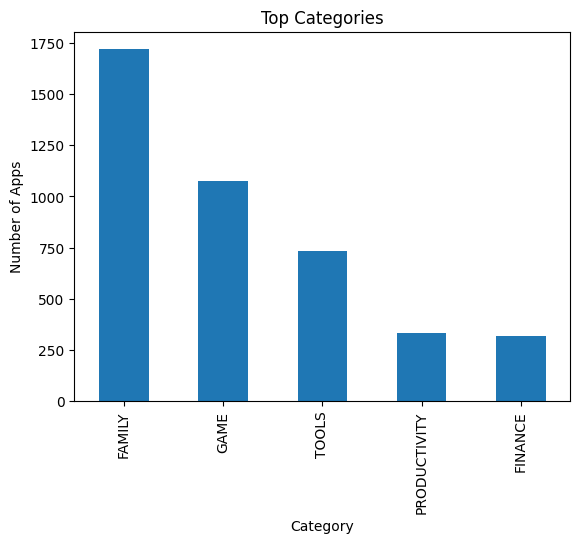

In [10]:
df['Category'].value_counts().head().plot(kind='bar')

plt.title("Top Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.show()

# 3. Free vs Paid

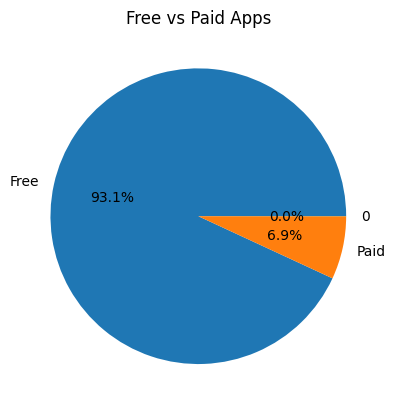

In [11]:
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.show()

# Export Clean Data

In [12]:
df.to_csv('cleaned_googleplaystore.csv', index=False)

In [32]:
df[['Installs','Rating']].corr()

,Installs,Rating
Installs,1.000000,0.054344
Rating,0.054344,1.000000
